In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# Decision Trees

- I closely followed Geron (2017) chapter 6
- Very versatile ML for classification and regression
- fundamental component of Random Forest (the most powerful ML algorithm today)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

### Introduction

1. what is it?

   - supervised leanring; predict target variable learning  thru data attributes (predictors)

2. important hyperparameters

    - `max_depth`: extent tree can reach
    - `min_sample_split`: minimum number of samples to  split
    - `min_samples_leaf`:

    - `class_weight`: imbalanced class case
    

3. pros and cons

    - simple, white box, feature importance
    - overfitting, unstable, not working well with unbalanced data
    


In [ ]:
from sklearn.tree import DecisionTreeClassifier


In [ ]:
?DecisionTreeClassifier

## Terminology

- root node: at the top (depth 0)
- child node: other than root node
- leaf node: don't have child node
- Gini(Impurity): $G_i = 1 - \sum_{k=1}^{n}p_{i,k}^2$
- $p_{i,k}$ is the ratio of class $k$ instances among $i^{th}$ node
- the degree of impurity: Gini=0 (all sample belongs to the classification)

### Entropy: Very much important

1. deeplearning: the most important loss function  (when optimization is unstable)

2. Uncertainty / amount of bytes to convey information

3. 금융
  - 시장의 불확실성: 만약에 엔트로피가 높으면 불확실성이 높고, 시장이 효율적으로 해석. 반면에 엔트로피가 낮으면, 불확실성이 없고, 시장이 비효율적으로 해석

      - trend: 예측 가능 --> 비효율적 (엔트로피가 낮은 경우)
      - mean reversion: 예측불가능 --> 효율적 (엔트로피가 높은 경우)

## Splitting and judgement Measures

- various measures (Gini, entropy) are used to increae purity as depth goes deeper

- Gini: $1-\sum p_i^2$
   - "prob. of a randomly selectd feature classifiying incorrectly"
- entropy: $1-\sum p_i \log{p_i}$

## More on Entropy

- **Entropy**: $H_i = \sum_{k=1}^{N}p_{i,k}log(p_{i,k})$,  excluding $p_{i,k}=0$
  - in physics: the degree of disorder, as entropy approaches 0, it is well ordered
  - in information theory: the amount of information: as entropy approaches, all messages are more identical
  

- Entroy in green-leaf-node in below example? (later)
  - $-\frac{49}{54}\log(\frac{49}{54})-\frac{5}{54}\log(\frac{5}{54})\approx0.308$
  

- In `sklearn` , Gini is default



- "Gini impurity tends to isolate the most frequent class in its own branch of the tree, while entropy tends to produce slightly more balanced trees."


# Example

In [ ]:
## common library

import numpy as np
import matplotlib.pyplot as plt
plt.style.use('seaborn')
import pandas as pd
import sklearn
from IPython.display import Image

<ipython-input-1-a99c4afe78b9>:5: MatplotlibDeprecationWarning: The seaborn styles shipped by Matplotlib are deprecated since 3.6, as they no longer correspond to the styles shipped by seaborn. However, they will remain available as 'seaborn-v0_8-<style>'. Alternatively, directly use the seaborn API instead.
  plt.style.use('seaborn')


In [ ]:
import tensorflow.keras.datasets as tmp

dir(tmp )

['__builtins__',
 '__cached__',
 '__doc__',
 '__file__',
 '__loader__',
 '__name__',
 '__package__',
 '__path__',
 '__spec__',
 'boston_housing',
 'cifar10',
 'cifar100',
 'fashion_mnist',
 'imdb',
 'mnist',
 'reuters']

In [ ]:
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris() # instantiation: class: __init__
#iris.keys()

In [ ]:
#dir(iris)
iris.target_names

array(['setosa', 'versicolor', 'virginica'], dtype='<U10')

In [ ]:
iris.data[:10]

array([[5.1, 3.5, 1.4, 0.2],
       [4.9, 3. , 1.4, 0.2],
       [4.7, 3.2, 1.3, 0.2],
       [4.6, 3.1, 1.5, 0.2],
       [5. , 3.6, 1.4, 0.2],
       [5.4, 3.9, 1.7, 0.4],
       [4.6, 3.4, 1.4, 0.3],
       [5. , 3.4, 1.5, 0.2],
       [4.4, 2.9, 1.4, 0.2],
       [4.9, 3.1, 1.5, 0.1]])

In [ ]:
## import data

from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier

iris = load_iris()  # data: sepal_length,  sepal_width,  petal_length, petal_width

X = iris.data[:, 2:]  # data/library specific
y = iris.target

clf = DecisionTreeClassifier(max_depth=3)
clf.fit(X, y)

DecisionTreeClassifier(max_depth=3)

In [ ]:
iris.feature_names

['sepal length (cm)',
 'sepal width (cm)',
 'petal length (cm)',
 'petal width (cm)']

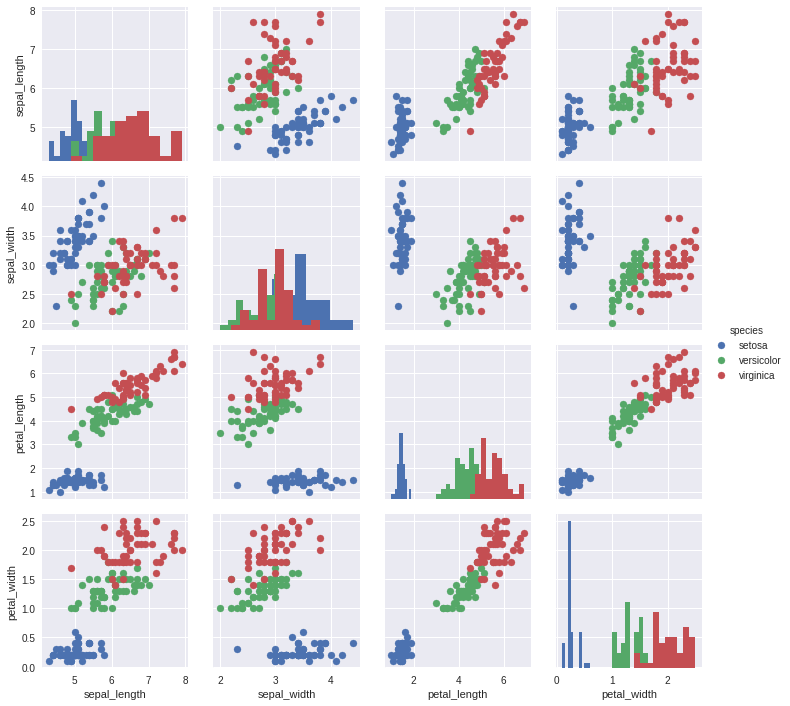

In [ ]:
# just for your reference
import seaborn as sns

iris_sns = sns.load_dataset("iris")
g = sns.PairGrid(iris_sns, hue="species")
g.map_diag(plt.hist)
g.map_offdiag(plt.scatter)
g.add_legend();

In [ ]:
#pip install pydotplus

In [ ]:
#pip install -c conda-forge python-graphviz

# and add path to system

In [ ]:
#conda install -c conda-forge python-graphviz

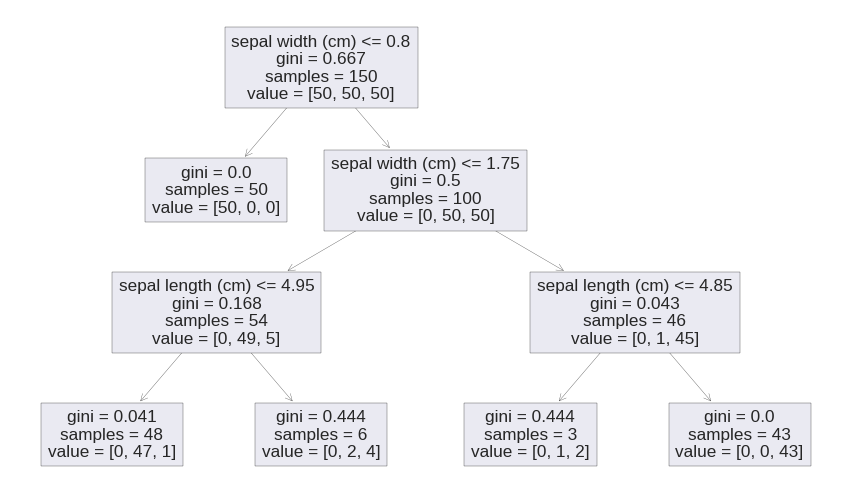

In [ ]:
from sklearn import tree

plt.figure(figsize=(15,9))
tree.plot_tree(clf, feature_names=iris.feature_names);

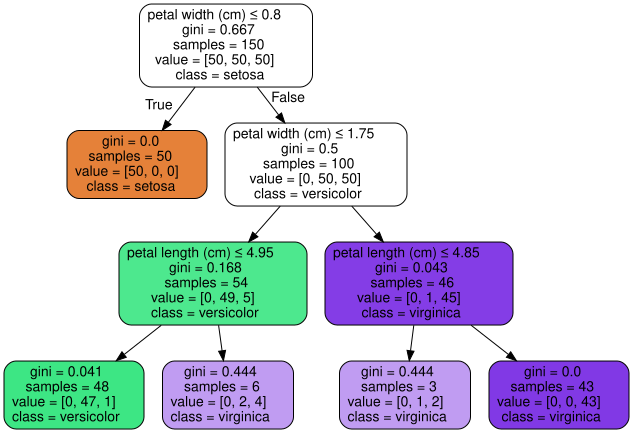

<Figure size 864x576 with 0 Axes>

In [ ]:
#pip install graphviz
import graphviz

dot_data = tree.export_graphviz(clf,
                  feature_names=iris.feature_names[2:],
                  class_names=iris.target_names,
                  filled=True, rounded=True,
                  special_characters=True,
                   out_file=None,
                           )

plt.figure(figsize=(12,8))
graph = graphviz.Source(dot_data)
graph

In [ ]:
if 'google.colab' in str(get_ipython):
  ImagePath = '/gdrive/MyDrive/Python/images/'
elif sys.platform.startswith('win'):
  ImagePath = 'G:/python/images'
else:
  ImagePath = '/mnt/G/python/images'

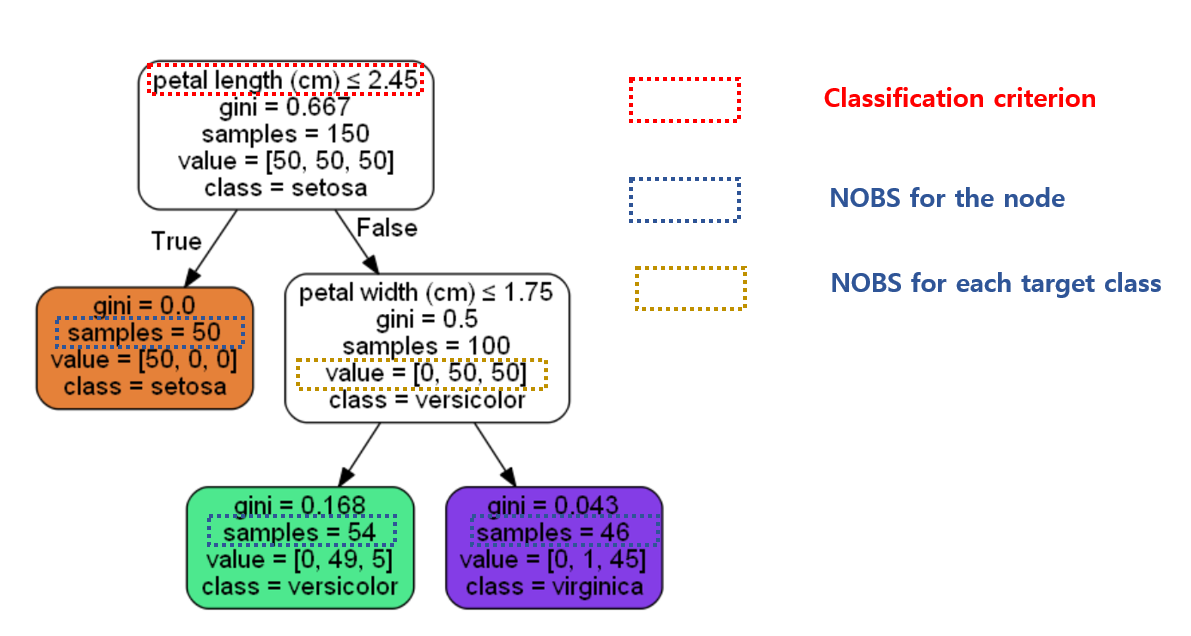

In [ ]:
Image(ImagePath+"Tree_Name.PNG", width=900, height=600)

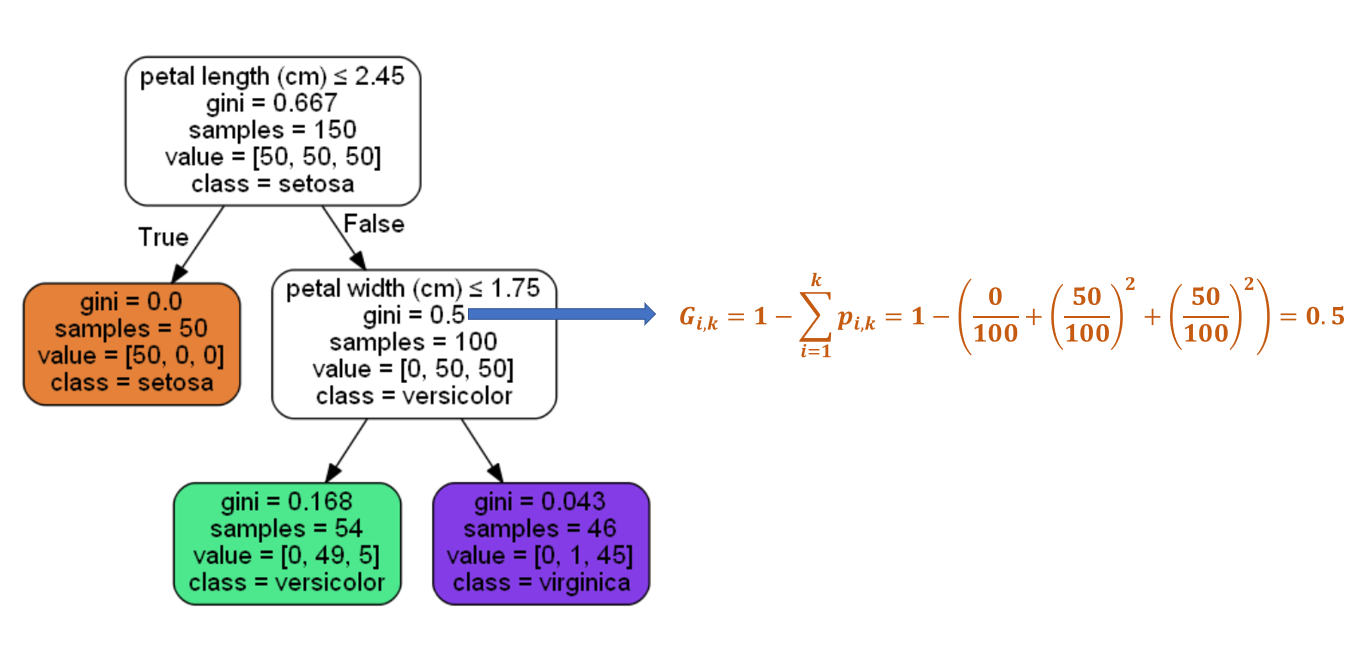

In [ ]:
Image("c:/python/images/Tree_Name2.PNG", width=900, height=300)

Text(4.05, 0.5, '(Depth=2)')

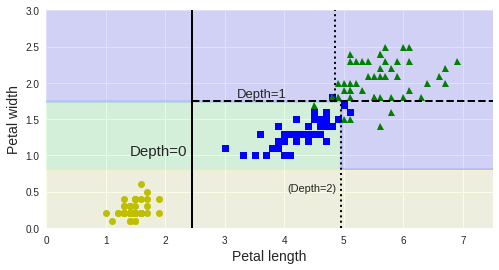

In [ ]:
plt.figure(figsize=(8, 4))
plot_decision_boundary(clf, X, y)  # SEE BELOW
plt.plot([2.45, 2.45], [0, 3], "k-", linewidth=2)
plt.plot([2.45, 7.5], [1.75, 1.75], "k--", linewidth=2)
plt.plot([4.95, 4.95], [0, 1.75], "k:", linewidth=2)
plt.plot([4.85, 4.85], [1.75, 3], "k:", linewidth=2)
plt.text(1.40, 1.0, "Depth=0", fontsize=15)
plt.text(3.2, 1.80, "Depth=1", fontsize=13)
plt.text(4.05, 0.5, "(Depth=2)", fontsize=11)

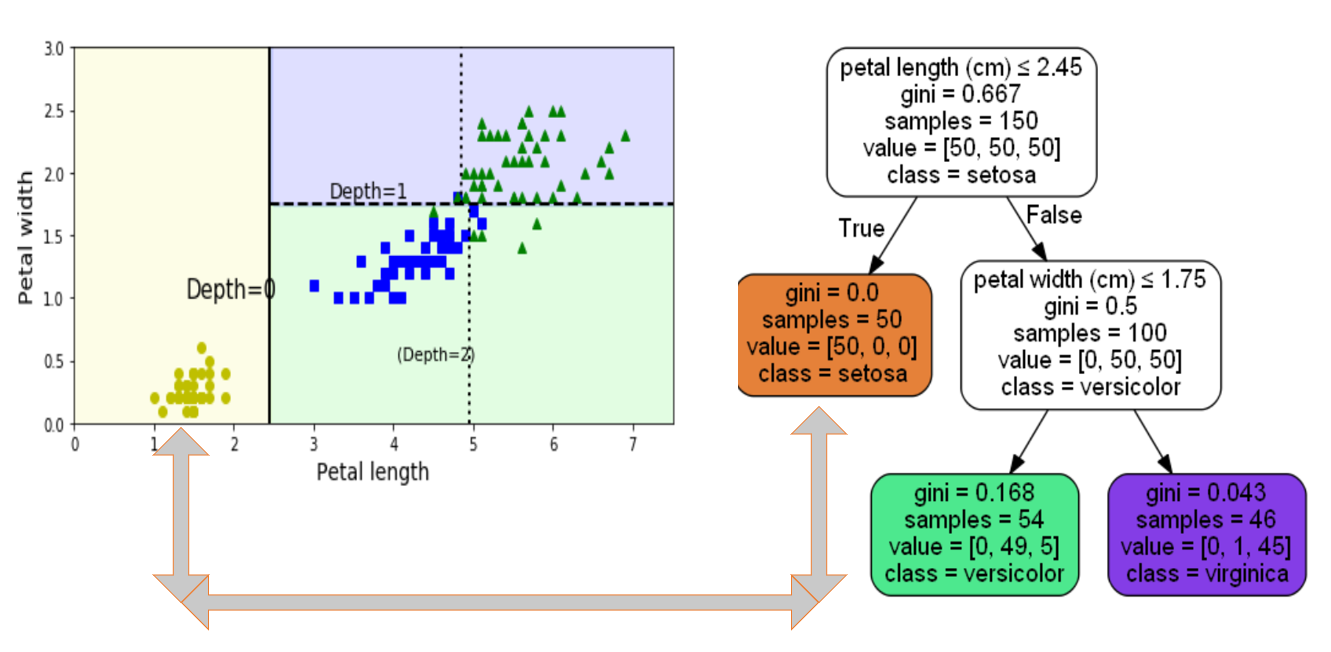

In [ ]:
Image(ImagePath+"Tree_Depth_Plus.PNG")

In [ ]:
### Class probability or classification

## assume that the petals were 6 cm long and 1.5 cm wide

print(clf.predict([[6,1.5]]))
print(clf.predict_proba([[6,1.5]]))

[2]
[[0.         0.33333333 0.66666667]]


### How to set the criterion(petal length $\le$ 2.45)?  

- `skelarn` uses CART(classfication and regression tree)
- CART searches $(feature_k, feature_{crtiteron})\equiv(k, t_k)$ such that
\begin{align*}
\min J_k \triangleq \frac{m_{left}}{m}G_{left} + \frac{m_{right}}{m}G_{right}
\end{align*}
  - where $m_{LR}$ is the nobs in the Left/Right subject
  - G: Gini coefficient
  
- Other hyperparameters (use for avoiding **overfitting**)
  - `max_depth`: when to stop in recursing
  - `min_samples_split`
  - `min_samples_leaf`

### problems?  Instability

- Tree is very simple and intuitive. However it's results changed depending on which feature variable comes first (sorting) and on outlier

In [ ]:
from matplotlib.colors import ListedColormap

def plot_decision_boundary(clf, X, y, axes=[0, 7.5, 0, 3], iris=True, legend=False, plot_training=True):
    x1s = np.linspace(axes[0], axes[1], 100)
    x2s = np.linspace(axes[2], axes[3], 100)
    x1, x2 = np.meshgrid(x1s, x2s)
    X_new = np.c_[x1.ravel(), x2.ravel()]
    y_pred = clf.predict(X_new).reshape(x1.shape)
    #custom_cmap = ListedColormap(['#fafab0','#9898ff','#a0faa0'])
    custom_cmap = ListedColormap(['#fafab0','#a0faa0', '#9898ff'])
    plt.contourf(x1, x2, y_pred, alpha=0.3, cmap=custom_cmap)
    if not iris:
        custom_cmap2 = ListedColormap(['#7d7d58','#4c4c7f','#507d50'])
        plt.contour(x1, x2, y_pred, cmap=custom_cmap2, alpha=0.8)
    if plot_training:
        plt.plot(X[:, 0][y==0], X[:, 1][y==0], "yo", label="Iris-Setosa")
        plt.plot(X[:, 0][y==1], X[:, 1][y==1], "bs", label="Iris-Versicolor")
        plt.plot(X[:, 0][y==2], X[:, 1][y==2], "g^", label="Iris-Virginica")
        plt.axis(axes)
    if iris:
        plt.xlabel("Petal length", fontsize=14)
        plt.ylabel("Petal width", fontsize=14)
    else:
        plt.xlabel(r"$x_1$", fontsize=18)
        plt.ylabel(r"$x_2$", fontsize=18, rotation=0)
    if legend:
        plt.legend(loc="lower right", fontsize=14)